In [1]:
import modules.utils as u
u.Devices()._cuda_list_gpus()

#### mv packages ####
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(drop=['cuda:1','cuda:6'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

data = d.Preprocessor(brca, kegg, kegg)
_dataset = d.GraphDataset(data)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:7

# #### KEGG() ####
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:7)
# edge_attr                (32464, 16)              Tensor (cuda:7)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:7)

# #### TCGA() ####
# counts_path              PosixPath
# metadata_path            PosixPath
# gene_name_path           PosixPath
# metadata_complete        (1231, 93)               DataFrame
# metadata                 (1172, 2)                DataFrame
# y                        (1172,)                  Tensor (cuda:7)
# y_labels                 5                        list
# ensgv                    (60660, 3)               DataFrame
# ensg_complete            19213                    list
# cou

In [2]:
import modules.train as t
import modules.model2 as m
from modules.layers import AttentionSetPooling

import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv

loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

dm = t.DataloaderMean(loader.train_loader, data.num_nodes, data.num_node_features)
x_mean = dm.get_mean(4)

ae = m.Autoencoder(
    # dims
    data=data,
    head_dim=32,
    num_heads=10,
    
    # nb
    nb=True,
    x_mean=x_mean,

    # layers
    encoder_class=nn.Linear,
    pooling_class=AttentionSetPooling,
    mlp=True,
    method='set',

    # layer params
    hidden_dims=[128,128,128], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,
)

trainer = t.NBReconTrainer(
    model=ae,
    loader=loader,
    num_epochs=30,
    loss_fn=nn.MSELoss(),
    optimizer_kwargs={'lr':5e-4},
    verbose=True,
    report_metrics=['loss','mae','rmse', 'r2'],
)

display(trainer.test_metrics)
# out = ae(_batch, need_weights=False)
# print(out.keys() if isinstance(out, dict) else out)
# print([k for k,v in out.items() if v is None])

100%|██████████| 30/30 [00:44<00:00,  1.48s/it, Epoch 29      Train: loss=10.6874    mae=0.7595    rmse=1.1250    r2=0.8414        Val: loss=10.7996    mae=0.7520    rmse=1.1353    r2=0.8378]

Test	 loss=10.6360    mae=0.7454    rmse=1.1143    r2=0.8441



{'loss': 10.636042594909668,
 'mean': 0.008778904564678669,
 'std': 1.114235520362854,
 'mae': 0.7454396486282349,
 'mse': 1.2415963411331177,
 'rmse': 1.1142693758010864,
 'r2': 0.8440638780593872}

In [3]:
import modules.viz as v

out = v.ModelOutput(
    model=trainer.model,
    dataset=_dataset,
)

/home/mv18gs/miniconda3/envs/thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

In [4]:
out.values.keys()

dict_keys(['lfc', 'mu', 'theta', 'h_ne', 'ne_out', 'h_pool', 'attn_n2s', 'h', 'z', 'z_node', 'z_set', 'attn_n2z', 'attn_s2z', 'attn_twin', 'lfc_recon', 'x_recon', 'x', 'y'])

In [5]:
type(out.values['lfc'])

numpy.ndarray

In [6]:
import numpy as np

for i in out.values.keys():
    if isinstance(out.values[i],np.ndarray):
        print(f'{i}: {out.values[i].shape}')

lfc: (5125156, 1)
mu: (5125156, 1)
theta: (5125156, 1)
h_ne: (5125156, 320)
h_pool: (1172, 305, 320)
attn_n2s: (1172, 4373, 305)
h: (1172, 305, 320)
z: (1172, 320)
z_set: (1172, 320)
attn_s2z: (1172, 305, 1)
lfc_recon: (5125156, 1)
x_recon: (5125156, 1)
x: (5125156, 1)
y: (1172,)


In [7]:
import seaborn as sns

<Axes: >

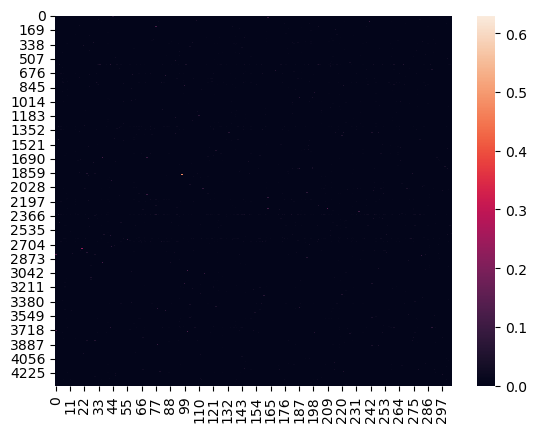

In [8]:
sns.heatmap(out.values['attn_n2s'].mean(axis=0))

<Axes: >

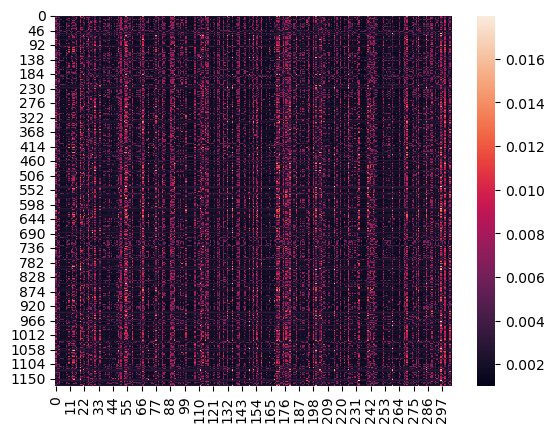

In [9]:
sns.heatmap(out.values['attn_s2z'].squeeze())

---

In [10]:
out.values['attn_s2z'].shape

(1172, 305, 1)

In [11]:
data.y.detach().cpu().numpy()

array([2, 2, 2, ..., 3, 1, 2], dtype=int8)

In [12]:
data.y_labels

['Basal', 'Her2', 'LumA', 'LumB', 'Solid Tissue Normal']

In [13]:
data.pathway_labels

['path:hsa04975',
 'path:hsa04010',
 'path:hsa04630',
 'path:hsa05030',
 'path:hsa05210',
 'path:hsa04137',
 'path:hsa05169',
 'path:hsa04114',
 'path:hsa05205',
 'path:hsa04520',
 'path:hsa05320',
 'path:hsa04666',
 'path:hsa00280',
 'path:hsa04672',
 'path:hsa05330',
 'path:hsa04068',
 'path:hsa05412',
 'path:hsa04668',
 'path:hsa00520',
 'path:hsa04061',
 'path:hsa00750',
 'path:hsa00563',
 'path:hsa05321',
 'path:hsa04613',
 'path:hsa00592',
 'path:hsa04979',
 'path:hsa04340',
 'path:hsa00240',
 'path:hsa04614',
 'path:hsa00030',
 'path:hsa00565',
 'path:hsa05222',
 'path:hsa04934',
 'path:hsa04911',
 'path:hsa04976',
 'path:hsa05417',
 'path:hsa04122',
 'path:hsa00630',
 'path:hsa00440',
 'path:hsa04915',
 'path:hsa04360',
 'path:hsa04371',
 'path:hsa05110',
 'path:hsa03018',
 'path:hsa00100',
 'path:hsa00670',
 'path:hsa00330',
 'path:hsa05031',
 'path:hsa05322',
 'path:hsa04512',
 'path:hsa05034',
 'path:hsa04964',
 'path:hsa04622',
 'path:hsa05150',
 'path:hsa00400',
 'path:hsa

---

In [14]:
import numpy as np
import pandas as pd

In [15]:
attn = out.values['attn_s2z'].squeeze()
labels = data.y.detach().cpu().numpy()

# unique class IDs
classes = np.unique(labels)

# split per class into dictionary
class_to_attn = {c: attn[labels == c] for c in classes}

# Example: class 0's attention scores
print(class_to_attn[0].shape)  # (num_samples_in_class0, num_pathways)


(197, 305)


In [16]:
data.pathway_labels

['path:hsa04975',
 'path:hsa04010',
 'path:hsa04630',
 'path:hsa05030',
 'path:hsa05210',
 'path:hsa04137',
 'path:hsa05169',
 'path:hsa04114',
 'path:hsa05205',
 'path:hsa04520',
 'path:hsa05320',
 'path:hsa04666',
 'path:hsa00280',
 'path:hsa04672',
 'path:hsa05330',
 'path:hsa04068',
 'path:hsa05412',
 'path:hsa04668',
 'path:hsa00520',
 'path:hsa04061',
 'path:hsa00750',
 'path:hsa00563',
 'path:hsa05321',
 'path:hsa04613',
 'path:hsa00592',
 'path:hsa04979',
 'path:hsa04340',
 'path:hsa00240',
 'path:hsa04614',
 'path:hsa00030',
 'path:hsa00565',
 'path:hsa05222',
 'path:hsa04934',
 'path:hsa04911',
 'path:hsa04976',
 'path:hsa05417',
 'path:hsa04122',
 'path:hsa00630',
 'path:hsa00440',
 'path:hsa04915',
 'path:hsa04360',
 'path:hsa04371',
 'path:hsa05110',
 'path:hsa03018',
 'path:hsa00100',
 'path:hsa00670',
 'path:hsa00330',
 'path:hsa05031',
 'path:hsa05322',
 'path:hsa04512',
 'path:hsa05034',
 'path:hsa04964',
 'path:hsa04622',
 'path:hsa05150',
 'path:hsa00400',
 'path:hsa

In [17]:
data.y_labels

['Basal', 'Her2', 'LumA', 'LumB', 'Solid Tissue Normal']

In [18]:
pathway_attn = pd.DataFrame(
    {
        'label':data.pathway_labels, 
        'global':attn.mean(axis=0),
        'basal':class_to_attn[0].mean(axis=0),
        'her2':class_to_attn[1].mean(axis=0),
        'lumA':class_to_attn[2].mean(axis=0),
        'lumB':class_to_attn[3].mean(axis=0),
        'norm':class_to_attn[4].mean(axis=0),
    }
)

pathway_attn = pathway_attn.sort_values(by='global', ascending=False)

pathway_attn

,label,global,basal,her2,lumA,lumB,norm
299,path:hsa00380,0.007091,0.007909,0.008455,0.006923,0.007710,0.004383
296,path:hsa04260,0.006909,0.004739,0.006675,0.007308,0.006565,0.009485
19,path:hsa04061,0.006757,0.007039,0.007413,0.006804,0.006301,0.006394
225,path:hsa04216,0.006745,0.006067,0.007050,0.007295,0.007433,0.003658
54,path:hsa00400,0.006457,0.005962,0.005605,0.006848,0.006909,0.005120
...,...,...,...,...,...,...,...
304,path:hsa00190,0.001840,0.001602,0.001603,0.001863,0.001594,0.002762
236,path:hsa05163,0.001840,0.001596,0.001606,0.001880,0.001566,0.002737
36,path:hsa04122,0.001839,0.001605,0.001595,0.001868,0.001574,0.002762
85,path:hsa04722,0.001832,0.001573,0.001618,0.001873,0.001564,0.002729


In [31]:
pathway_attn.to_csv('recon_pathway_attn.csv', index=False)

<Axes: ylabel='label'>

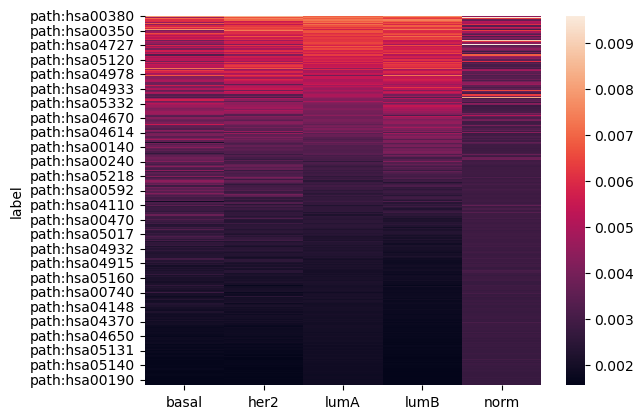

In [19]:
sns.heatmap(pathway_attn.drop(columns=['global']).set_index('label'))

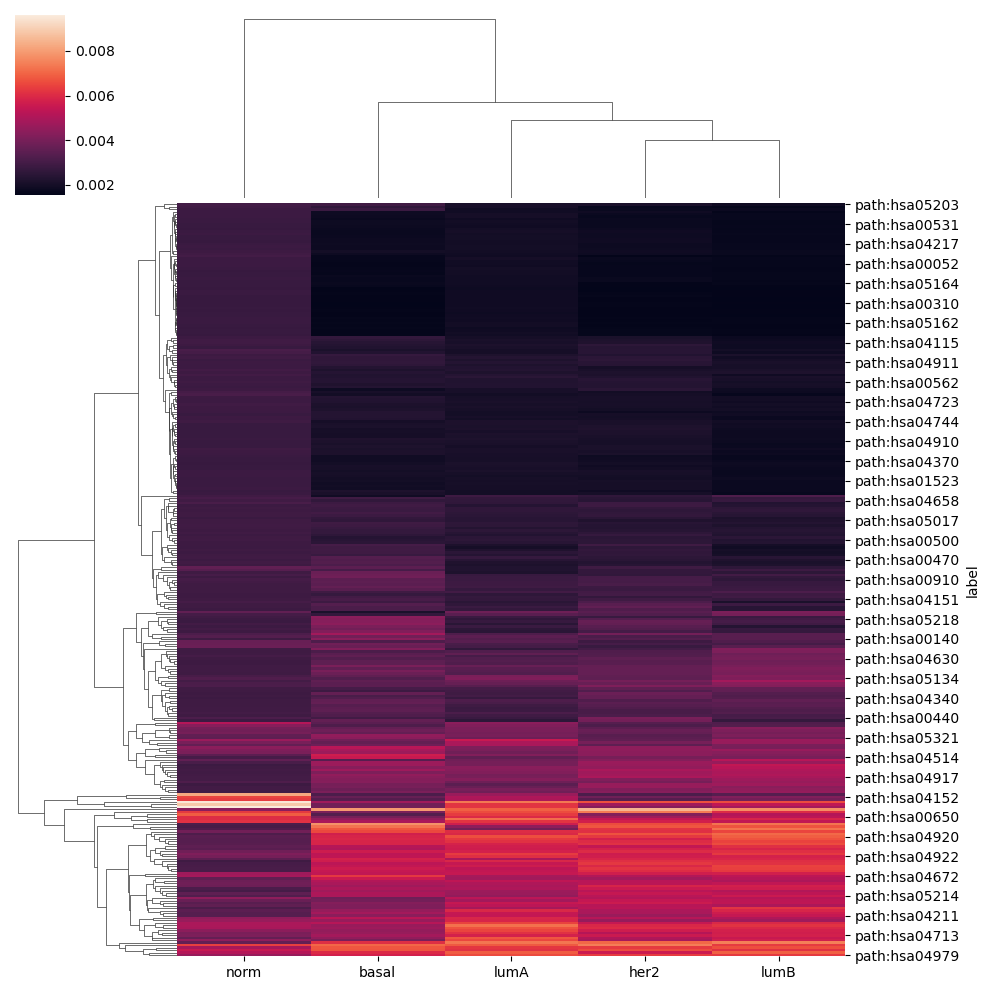

In [20]:
sns.clustermap(pathway_attn.drop(columns=['global']).set_index('label'))

<Axes: xlabel='global', ylabel='Density'>

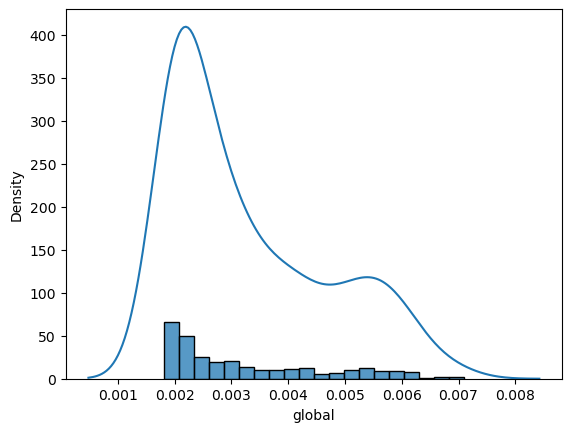

In [21]:
sns.kdeplot(pathway_attn['global'])
sns.histplot(pathway_attn['global'], bins=20)

---

In [22]:
attn = out.values['attn_s2z'].squeeze()
labels = data.y.detach().cpu().numpy()

# unique class IDs
classes = np.unique(labels)

# split per class into dictionary
class_to_attn = {c: attn[labels == c] for c in classes}

# Example: class 0's attention scores
print(class_to_attn[0].shape)  # (num_samples_in_class0, num_pathways)


(197, 305)


In [23]:
n2s = out.values['attn_n2s']

labels = data.y.detach().cpu().numpy()
classes = np.unique(labels)

class_n2s = {c: n2s[labels == c] for c in classes}

<Axes: >

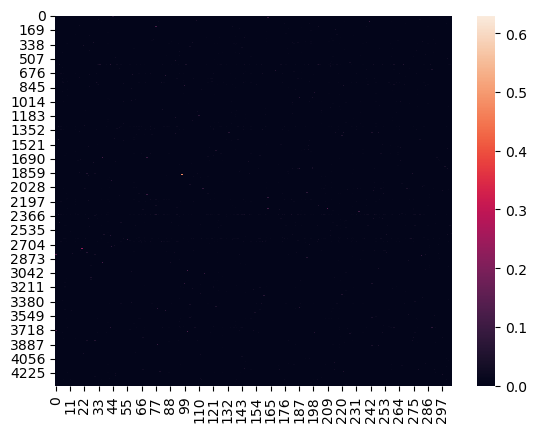

In [24]:
sns.heatmap(n2s.mean(axis=0))

In [25]:
node_attn = pd.DataFrame({
    'labels':data.x_labels,
    'global':n2s.mean(0).mean(-1),
    'basal':class_n2s[0].mean(0).mean(-1),
    'her2':class_n2s[1].mean(0).mean(-1),
    'lumA':class_n2s[2].mean(0).mean(-1),
    'lumB':class_n2s[3].mean(0).mean(-1),
    'norm':class_n2s[4].mean(0).mean(-1),
})

# node_attn = pd.DataFrame({
#     'labels':data.x_labels,
#     'global':n2s.mean(0).sum(-1),
#     'basal':class_n2s[0].mean(0).sum(-1),
#     'her2':class_n2s[1].mean(0).sum(-1),
#     'lumA':class_n2s[2].mean(0).sum(-1),
#     'lumB':class_n2s[3].mean(0).sum(-1),
#     'norm':class_n2s[4].mean(0).sum(-1),
# })

node_attn = node_attn.sort_values(by='global', ascending=False)

node_attn

,labels,global,basal,her2,lumA,lumB,norm
1361,AKT3,0.004790,0.004803,0.004817,0.004775,0.004946,0.004538
817,CD40LG,0.004717,0.004493,0.004538,0.004807,0.004869,0.004495
2347,PIK3R1,0.004566,0.004884,0.004430,0.004483,0.004824,0.004054
835,MAPK3,0.004543,0.004530,0.004469,0.004551,0.004506,0.004652
686,MAPK1,0.004520,0.004493,0.004481,0.004523,0.004487,0.004643
...,...,...,...,...,...,...,...
3522,ZNF454,0.000008,0.000008,0.000007,0.000007,0.000008,0.000008
882,IL7,0.000007,0.000008,0.000008,0.000007,0.000007,0.000011
3677,ZNF730,0.000007,0.000007,0.000007,0.000007,0.000007,0.000008
3544,ZNF552,0.000007,0.000007,0.000008,0.000007,0.000007,0.000008


In [32]:
node_attn.to_csv('recon_pathway_node.csv', index=False)

In [26]:
node_attn.head(50)

,labels,global,basal,her2,lumA,lumB,norm
1361,AKT3,0.004790,0.004803,0.004817,0.004775,0.004946,0.004538
817,CD40LG,0.004717,0.004493,0.004538,0.004807,0.004869,0.004495
2347,PIK3R1,0.004566,0.004884,0.004430,0.004483,0.004824,0.004054
835,MAPK3,0.004543,0.004530,0.004469,0.004551,0.004506,0.004652
686,MAPK1,0.004520,0.004493,0.004481,0.004523,0.004487,0.004643
918,AKT2,0.004382,0.004336,0.004429,0.004375,0.004341,0.004541
2213,AKT1,0.004331,0.004271,0.004364,0.004317,0.004306,0.004523
3284,PIK3CD,0.004026,0.003964,0.003928,0.004015,0.004103,0.004113
1488,PIK3CA,0.003985,0.003874,0.004001,0.004037,0.003870,0.004121
1380,PIK3R3,0.003951,0.003818,0.003977,0.003991,0.003917,0.004031


<Axes: xlabel='global', ylabel='Density'>

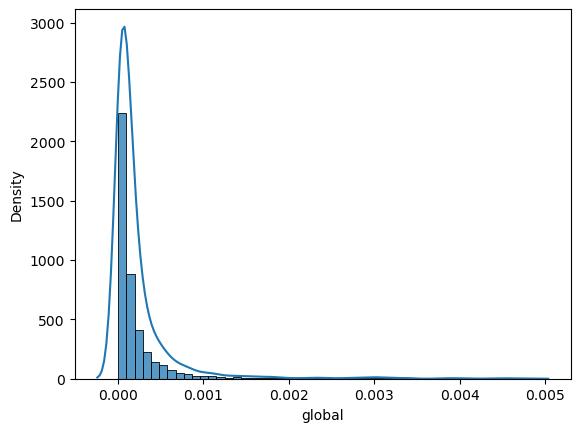

In [27]:
sns.kdeplot(node_attn['global'])
sns.histplot(node_attn['global'], bins=50)

<Axes: ylabel='labels'>

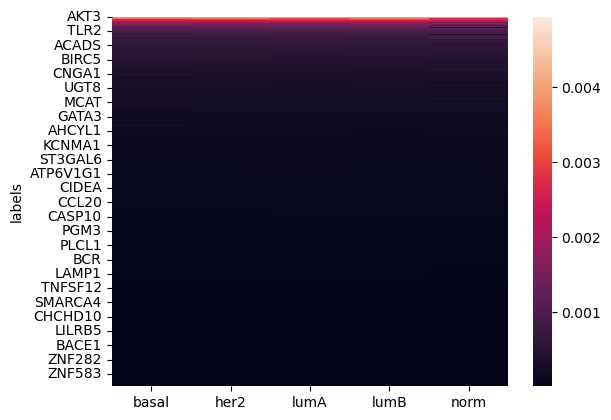

In [28]:
sns.heatmap(node_attn.drop(columns=['global']).set_index('labels'))

/home/mv18gs/miniconda3/envs/thesis/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/mv18gs/miniconda3/envs/thesis/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


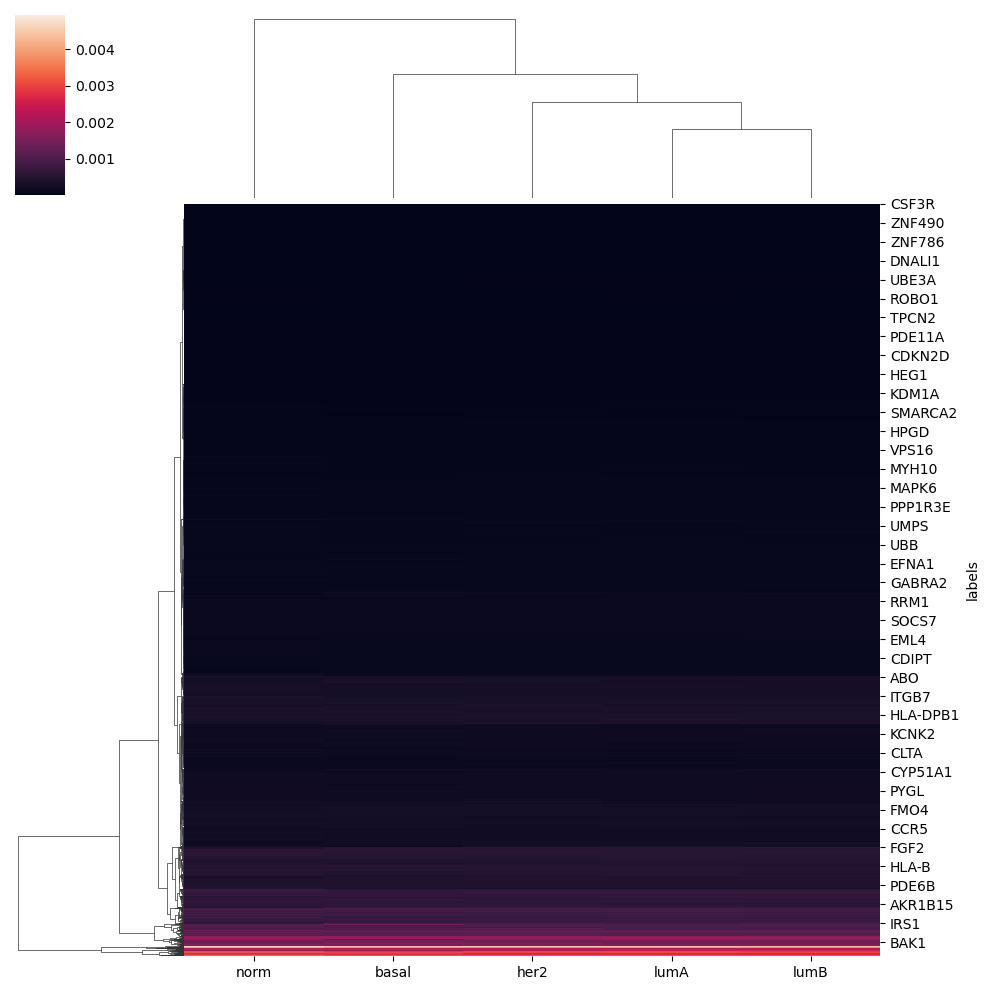

In [29]:
sns.clustermap(node_attn.drop(columns=['global']).set_index('labels'))